In [ ]:
import io, os
import numpy as np, pandas as pd, matplotlib.pyplot as plt, soundfile as sf
from datasets import load_dataset, Audio

LABEL_HOP = 512          # each reference label covers 512 samples = 32 ms at 16 kHz

In [2]:
dataset = load_dataset("guynich/librispeech_asr_test_vad", split="test.clean")
dataset = dataset.cast_column("audio", Audio(decode=False))

file_names = dataset["file"]
speaker_of = [os.path.basename(str(f)).split("-")[0] for f in file_names]

N_PER_SPEAKER = 3
rng = np.random.default_rng(42)
selected = []
for speaker in sorted(set(speaker_of)):
    idx = [i for i, s in enumerate(speaker_of) if s == speaker]
    selected += list(rng.choice(idx, size=min(N_PER_SPEAKER, len(idx)), replace=False))

recordings = []
for i in selected:
    sample = dataset[int(i)]
    audio = sample["audio"]
    source = io.BytesIO(audio["bytes"]) if audio["bytes"] is not None else audio["path"]
    y, sr = sf.read(source)
    if y.ndim > 1:
        y = y.mean(axis=1)
    reference = np.asarray(sample["speech"], dtype=int)
    valid = np.asarray(sample["confidence"], dtype=int) == 1
    n_blocks = len(reference)
    y = np.pad(y, (0, max(0, n_blocks * LABEL_HOP - len(y))))[:n_blocks * LABEL_HOP]
    recordings.append({"id": os.path.basename(str(sample["file"])), "speaker": speaker_of[i], "y": y,
                       "reference": reference, "valid": valid, "n_blocks": n_blocks})

print("Speakers:", len(set(r["speaker"] for r in recordings)), "| Recordings:", len(recordings),
      "| Audio:", round(sum(len(r["y"]) for r in recordings) / sr / 60, 1), "min")

Speakers: 40 | Recordings: 120 | Audio: 17.3 min


In [3]:
def make_noise(n, kind, rng):
    """white: flat spectrum | fluctuating: pink noise whose level drifts over time."""
    white = rng.normal(size=n)
    if kind == "white":
        return white
    spectrum = np.fft.rfft(white)
    freqs = np.fft.rfftfreq(n)
    freqs[0] = freqs[1]
    pink = np.fft.irfft(spectrum / np.sqrt(freqs), n=n)
    control = rng.normal(size=int(n / sr * 5) + 2) * 4.0
    gain_db = np.interp(np.arange(n), np.linspace(0, n, len(control)), control)
    return pink * 10 ** (gain_db / 20)

CONDITIONS = {"clean": None, "white 10 dB": ("white", 10), "fluctuating 10 dB": ("fluctuating", 10)}

# Build every version of every recording once
for index, r in enumerate(recordings):
    mask = np.repeat(r["reference"] == 1, LABEL_HOP)
    r["signals"] = {}
    for name, setting in CONDITIONS.items():
        if setting is None:
            r["signals"][name] = r["y"]
            continue
        kind, snr_db = setting
        noise = make_noise(len(r["y"]), kind, np.random.default_rng(index))
        power = np.mean(r["y"][mask] ** 2) if mask.any() else np.mean(r["y"] ** 2)
        r["signals"][name] = r["y"] + noise * np.sqrt(power / (np.mean(noise ** 2) * 10 ** (snr_db / 10)))

    # Label blocks close to a speech/non-speech transition (2 blocks = 64 ms on each side)
    change = np.where(np.diff(r["reference"]) != 0)[0] + 1
    near = np.zeros(r["n_blocks"], dtype=bool)
    for c in change:
        near[max(0, c - 2):c + 2] = True
    r["boundary"] = near

In [4]:
def frame_energy_db(signal, frame_ms, hop_ms):
    """Energy (dB) of frames of length frame_ms taken every hop_ms.

    Frame i is centred on sample 256 + i * hop, so with hop = 32 ms every frame sits exactly
    on the centre of a label block. Reflect padding keeps the first and last frames full.
    A cumulative sum makes this fast for any frame length.
    """
    length = int(sr * frame_ms / 1000)
    hop = int(sr * hop_ms / 1000)
    padded = np.pad(signal, length, mode="reflect")
    cumulative = np.concatenate([[0.0], np.cumsum(padded ** 2)])
    centres = np.arange(LABEL_HOP // 2, len(signal), hop)
    start = centres + length - length // 2                 # position of the frame start in the padded signal
    energy = (cumulative[start + length] - cumulative[start]) / length
    return 10 * np.log10(energy + 1e-20), centres

def block_to_frame(centres, n_blocks):
    """For every label block, the index of the frame whose centre is closest to the block centre."""
    block_centres = np.arange(n_blocks) * LABEL_HOP + LABEL_HOP // 2
    right = np.clip(np.searchsorted(centres, block_centres), 1, len(centres) - 1)
    left = right - 1
    return np.where(block_centres - centres[left] <= centres[right] - block_centres, left, right)

def counts(true, pred):
    return {"TP": int(np.sum((true == 1) & (pred == 1))), "TN": int(np.sum((true == 0) & (pred == 0))),
            "FP": int(np.sum((true == 0) & (pred == 1))), "FN": int(np.sum((true == 1) & (pred == 0)))}

def rates(c):
    miss = c["FN"] / (c["TP"] + c["FN"]) if c["TP"] + c["FN"] else np.nan
    fa = c["FP"] / (c["FP"] + c["TN"]) if c["FP"] + c["TN"] else np.nan
    return pd.Series({"miss_rate": miss, "false_alarm_rate": fa, "balanced_accuracy": 1 - (miss + fa) / 2})

def summarise(frame, by):
    return frame.groupby(by, observed=True)[["TP", "TN", "FP", "FN"]].sum().apply(rates, axis=1)

def th_robust_db(db, k=1.5, cap_db=6.0, range_db=60.0):
    """Label-free threshold from EXP-04 (in dB)."""
    clipped = np.maximum(db, np.percentile(db, 95) - range_db)
    p5, p10, p20 = np.percentile(clipped, [5, 10, 20])
    return p10 + min(max(k * (p20 - p5), 1.0), cap_db)

def th_oracle_db(block_db, rec):
    """Best threshold for this recording, chosen with its labels (upper bound)."""
    true, valid = rec["reference"][rec["valid"]], rec["valid"]
    values = block_db[valid]
    candidates = np.linspace(np.percentile(values, 1), np.percentile(values, 99), 80)
    best_score, best_th = -1, candidates[0]
    for th in candidates:
        pred = values > th
        tp = np.sum(pred & (true == 1)); tn = np.sum(~pred & (true == 0))
        pos = max(np.sum(true == 1), 1); neg = max(np.sum(true == 0), 1)
        score = (tp / pos + tn / neg) / 2
        if score > best_score:
            best_score, best_th = score, th
    return best_th

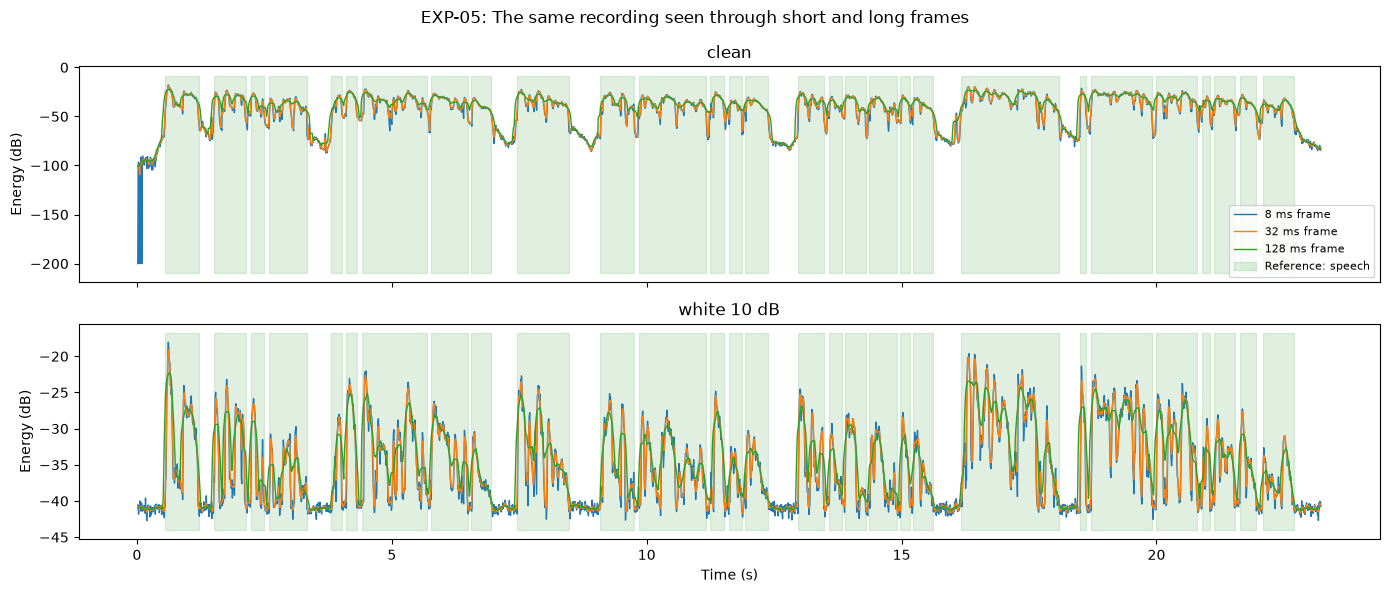

In [5]:
r = max(recordings, key=lambda rec: len(np.where(np.diff(rec["reference"]) != 0)[0]))   # recording with most pauses
edges = np.arange(r["n_blocks"] + 1) * LABEL_HOP / sr

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
for ax, condition in zip(axes, ["clean", "white 10 dB"]):
    for frame_ms in [8, 32, 128]:
        db, centres = frame_energy_db(r["signals"][condition], frame_ms, 8)
        ax.plot(centres / sr, db, linewidth=1, label=f"{frame_ms} ms frame")
    low, high = ax.get_ylim()
    ax.fill_between(edges[:-1], low, high, where=r["reference"] == 1, step="post", alpha=0.12,
                    color="green", label="Reference: speech")
    ax.set_ylabel("Energy (dB)"); ax.set_title(condition)
axes[0].legend(fontsize=8, loc="lower right"); axes[1].set_xlabel("Time (s)")
plt.suptitle("EXP-05: The same recording seen through short and long frames"); plt.tight_layout(); plt.show()

In [6]:
def evaluate(frame_ms, hop_ms, transform=None):
    """Run one frame/hop setting over all recordings and conditions. Returns one row per recording and method."""
    rows = []
    for r in recordings:
        true, valid = r["reference"][r["valid"]], r["valid"]
        for condition, signal in r["signals"].items():
            db, centres = frame_energy_db(signal, frame_ms, hop_ms)
            if transform is not None:
                db = transform(db)
            block_db = db[block_to_frame(centres, r["n_blocks"])]

            # Separation of the two classes (digital silence clipped so it cannot dominate the statistics)
            stats_db = np.maximum(block_db, np.percentile(block_db, 95) - 60)
            silence, speech = stats_db[valid & (r["reference"] == 0)], stats_db[valid & (r["reference"] == 1)]
            separation = ((speech.mean() - silence.mean()) / np.sqrt((speech.var() + silence.var()) / 2 + 1e-12)
                          if len(silence) >= 5 and len(speech) >= 5 else np.nan)

            for method, th in [("label-free", th_robust_db(db)), ("oracle", th_oracle_db(block_db, r))]:
                pred = (block_db > th).astype(int)
                near = r["boundary"][valid]
                wrong = pred[valid] != true
                rows.append({"frame_ms": frame_ms, "hop_ms": hop_ms, "condition": condition, "method": method,
                             **counts(true, pred[valid]),
                             "boundary_errors": int(wrong[near].sum()), "boundary_total": int(near.sum()),
                             "interior_errors": int(wrong[~near].sum()), "interior_total": int((~near).sum()),
                             "separation": separation})
    return pd.DataFrame(rows)

FRAMES = [8, 16, 32, 64, 128, 256]
frame_results = pd.concat([evaluate(frame_ms, 8) for frame_ms in FRAMES])
accuracy = summarise(frame_results, ["method", "condition", "frame_ms"])["balanced_accuracy"].unstack()
display(accuracy.round(3))

frame_ms                        8      16     32     64     128    256
method     condition                                                  
label-free clean              0.895  0.902  0.910  0.913  0.897  0.835
           fluctuating 10 dB  0.780  0.792  0.802  0.821  0.832  0.801
           white 10 dB        0.892  0.917  0.933  0.932  0.909  0.824
oracle     clean              0.953  0.957  0.964  0.962  0.948  0.904
           fluctuating 10 dB  0.815  0.825  0.839  0.862  0.886  0.881
           white 10 dB        0.912  0.927  0.948  0.955  0.947  0.904

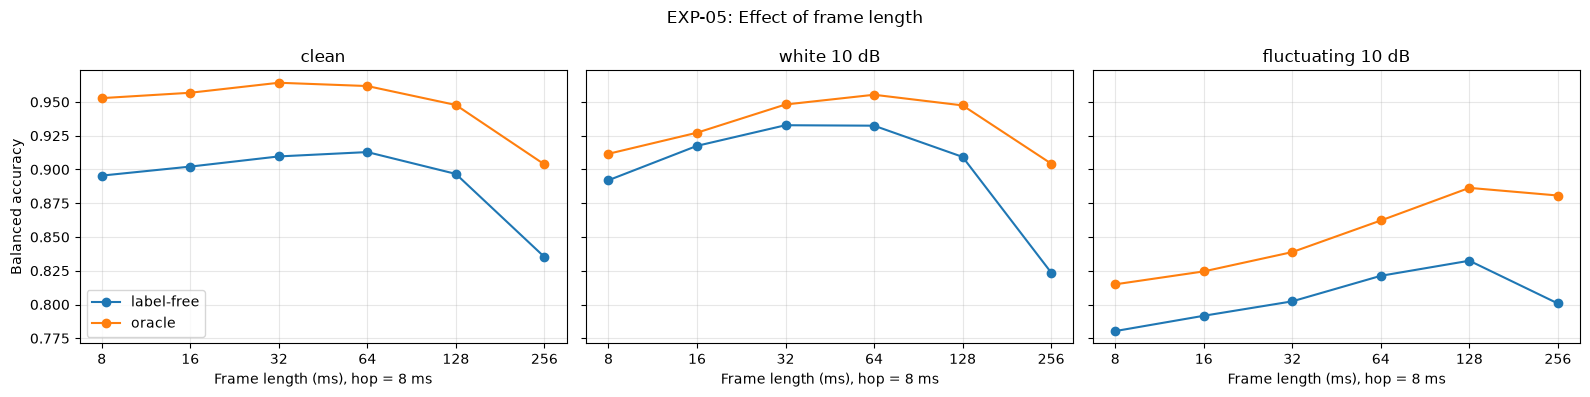

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)
for ax, condition in zip(axes, CONDITIONS):
    for method in ["label-free", "oracle"]:
        ax.plot(range(len(FRAMES)), accuracy.loc[(method, condition)], marker="o", label=method)
    ax.set_xticks(range(len(FRAMES))); ax.set_xticklabels(FRAMES)
    ax.set_title(condition); ax.set_xlabel("Frame length (ms), hop = 8 ms"); ax.grid(alpha=0.3)
axes[0].set_ylabel("Balanced accuracy"); axes[0].legend()
plt.suptitle("EXP-05: Effect of frame length"); plt.tight_layout(); plt.show()

separation  interior_error_rate  \
condition         frame_ms                                    
clean             8              3.542                0.036   
                  16             3.691                0.031   
                  32             3.939                0.023   
                  64             4.061                0.013   
                  128            3.697                0.009   
                  256            2.714                0.022   
fluctuating 10 dB 8              1.725                0.188   
                  16             1.799                0.179   
                  32             1.934                0.162   
                  64             2.151                0.131   
                  128            2.381                0.079   
                  256            2.252                0.056   
white 10 dB       8              1.952                0.091   
                  16             2.023                0.068   
                  32             2.156                0.043   
                  64             2.388                0.022   
                  128            2.651                0.009   
                  256            2.460                0.023   

                            boundary_error_rate  
condition         frame_ms                       
clean             8                       0.189  
                  16                      0.175  
                  32                      0.162  
                  64                      0.149  
                  128                     0.161  
                  256                     0.237  
fluctuating 10 dB 8                       0.434  
                  16                      0.426  
                  32                      0.393  
                  64                      0.370  
                  128                     0.330  
                  256                     0.321  
white 10 dB       8                       0.341  
                  16                      0.299  
                  32                      0.231  
                  64                      0.199  
                  128                     0.170  
                  256                     0.241

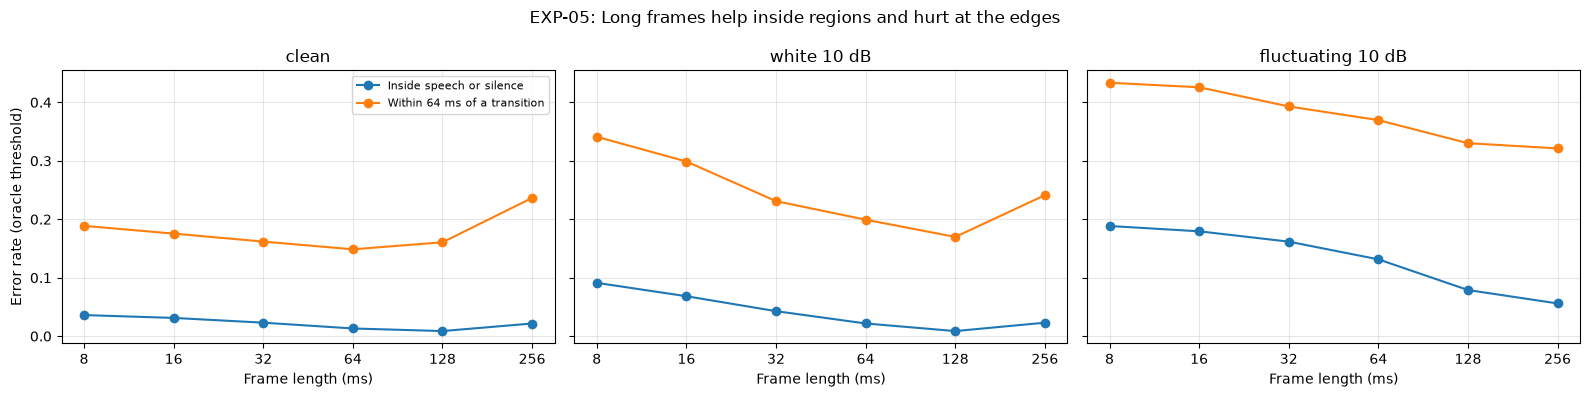

In [8]:
oracle = frame_results[frame_results["method"] == "oracle"]
why = oracle.groupby(["condition", "frame_ms"]).agg(
    separation=("separation", "mean"),
    boundary_errors=("boundary_errors", "sum"), boundary_total=("boundary_total", "sum"),
    interior_errors=("interior_errors", "sum"), interior_total=("interior_total", "sum"))
why["interior_error_rate"] = why["interior_errors"] / why["interior_total"]
why["boundary_error_rate"] = why["boundary_errors"] / why["boundary_total"]
why = why[["separation", "interior_error_rate", "boundary_error_rate"]]
display(why.round(3))

fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)
for ax, condition in zip(axes, CONDITIONS):
    part = why.loc[condition]
    ax.plot(range(len(FRAMES)), part["interior_error_rate"], marker="o", label="Inside speech or silence")
    ax.plot(range(len(FRAMES)), part["boundary_error_rate"], marker="o", label="Within 64 ms of a transition")
    ax.set_xticks(range(len(FRAMES))); ax.set_xticklabels(FRAMES)
    ax.set_title(condition); ax.set_xlabel("Frame length (ms)"); ax.grid(alpha=0.3)
axes[0].set_ylabel("Error rate (oracle threshold)"); axes[0].legend(fontsize=8)
plt.suptitle("EXP-05: Long frames help inside regions and hurt at the edges"); plt.tight_layout(); plt.show()

In [9]:
HOPS = [4, 8, 16, 32, 64, 128]
hop_results = pd.concat([evaluate(32, hop_ms) for hop_ms in HOPS])
hop_table = summarise(hop_results[hop_results["method"] == "label-free"],
                      ["condition", "hop_ms"])["balanced_accuracy"].unstack()
hop_table.loc["frames per second"] = [1000 / h for h in HOPS]
display(hop_table.round(3))

hop_ms,4,8,16,32,64,128
condition,,,,,,
clean,0.910,0.910,0.910,0.911,0.914,0.895
fluctuating 10 dB,0.804,0.802,0.803,0.802,0.805,0.790
white 10 dB,0.933,0.933,0.933,0.932,0.931,0.912
frames per second,250.000,125.000,62.500,31.250,15.625,7.812


In [10]:
def smooth_db(frames):
    """Moving average of the dB energy over the given number of frames."""
    def apply(db):
        kernel = np.ones(frames) / frames
        return np.convolve(np.pad(db, (frames // 2, frames - 1 - frames // 2), mode="edge"), kernel, mode="valid")
    return apply

alternatives = {
    "16 ms frame": evaluate(16, 8),
    "128 ms frame": evaluate(128, 8),
    "16 ms frame + smoothing over 128 ms": evaluate(16, 8, transform=smooth_db(15)),
}
rows = []
for name, frame in alternatives.items():
    part = summarise(frame, ["method", "condition"])["balanced_accuracy"].unstack()
    for method in ["label-free", "oracle"]:
        rows.append({"setting": name, "method": method, **part.loc[method].to_dict()})
display(pd.DataFrame(rows).set_index(["method", "setting"]).sort_index().round(3))

clean  fluctuating 10 dB  \
method     setting                                                         
label-free 128 ms frame                         0.897              0.832   
           16 ms frame                          0.902              0.792   
           16 ms frame + smoothing over 128 ms  0.920              0.818   
oracle     128 ms frame                         0.948              0.886   
           16 ms frame                          0.957              0.825   
           16 ms frame + smoothing over 128 ms  0.974              0.870   

                                                white 10 dB  
method     setting                                           
label-free 128 ms frame                               0.909  
           16 ms frame                                0.917  
           16 ms frame + smoothing over 128 ms        0.918  
oracle     128 ms frame                               0.947  
           16 ms frame                                0.927  
           16 ms frame + smoothing over 128 ms        0.953

In [11]:
os.makedirs("../results", exist_ok=True)
accuracy.to_csv("../results/exp05_frame_length.csv")
why.to_csv("../results/exp05_frame_length_why.csv")
hop_table.to_csv("../results/exp05_hop.csv")
print("Saved.")

Saved.
